[*********************100%***********************]  4 of 4 completed



VIF:
         Feature       VIF
0   hdfc_lagged  1.287654
1   nse_returns  4.316879
2  bank_returns  3.919855
3      momentum  1.282701
4    volatility  1.003015
5           vix  1.563478
hdfc_returns → p-value: 0.0000
nse_returns → p-value: 0.0000
bank_returns → p-value: 0.0000
hdfc_lagged → p-value: 0.0000
volatility → p-value: 0.0496
momentum → p-value: 0.0000
vix → p-value: 0.0000
                            OLS Regression Results                            
Dep. Variable:           hdfc_returns   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     231.3
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          9.75e-182
Time:                        16:45:43   Log-Likelihood:                 3199.6
No. Observations:                 955   AIC:                            -6385.
Df Residuals:                     948   BIC:              

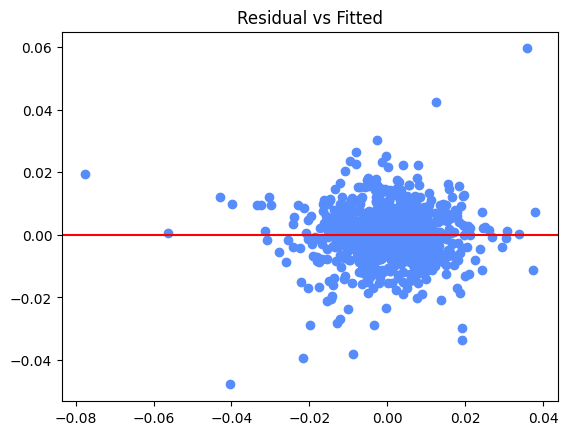

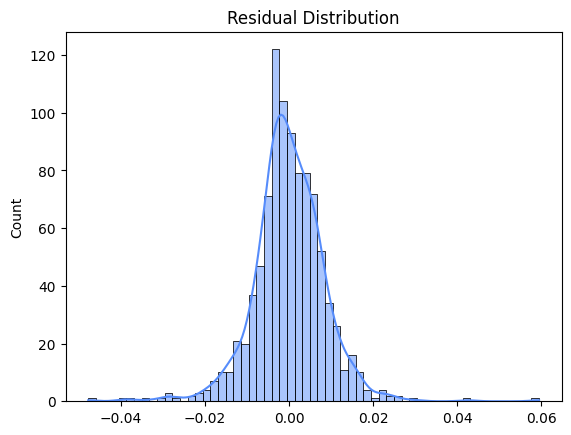

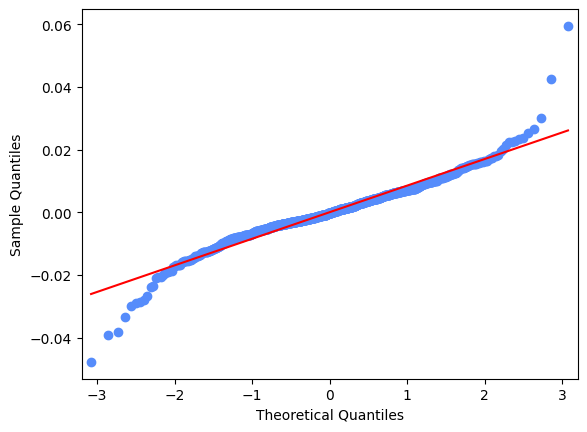

Skew: 0.0057834925504523585
Kurtosis: 5.3909274034289645
Durbin-Watson: 2.0091286721623196
Breusch-Pagan p-value: 0.1379014393854949


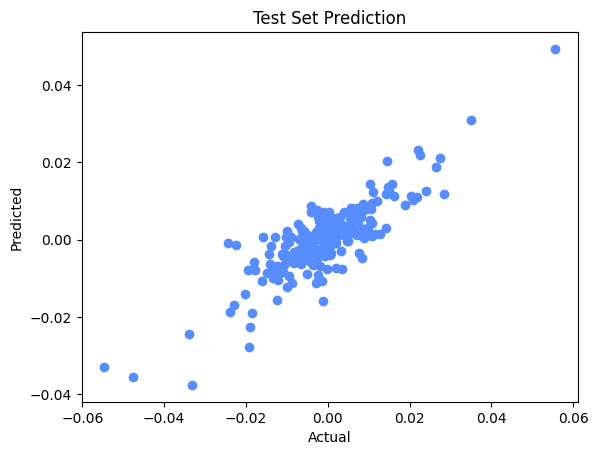


Model built successfully with proper:
- No data leakage
- Consistent train/test features
- Diagnostics completed


In [1]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LinearRegression


# -------------------------------
# 2. DOWNLOAD DATA
# -------------------------------

end = dt.date.today()
start = end - dt.timedelta(days=365*5)

tickers = ['HDFCBANK.NS','^NSEI','^INDIAVIX','^NSEBANK']

# Download adjusted close prices
df = yf.download(tickers=tickers, start=start, end=end, auto_adjust=True)['Close']


# -------------------------------
# 3. FEATURE ENGINEERING
# -------------------------------

# Log returns (stationary, better for modeling)
df['hdfc_returns'] = np.log(df['HDFCBANK.NS'] / df['HDFCBANK.NS'].shift(1))
df['nse_returns'] = np.log(df['^NSEI'] / df['^NSEI'].shift(1))
df['bank_returns'] = np.log(df['^NSEBANK'] / df['^NSEBANK'].shift(1))

# Lagged return (previous day information)
df['hdfc_lagged'] = df['hdfc_returns'].shift(1)

# Rolling volatility (use only past info → shift to avoid leakage)
df['volatility'] = df['hdfc_returns'].rolling(20).std().shift(1)

# Momentum (past 5-day return → shift to avoid leakage)
df['momentum'] = df['HDFCBANK.NS'].pct_change(5).shift(1)

# VIX returns (instead of raw level)
df['vix'] = np.log(df['^INDIAVIX'] / df['^INDIAVIX'].shift(1))


# -------------------------------
# 4. CLEAN DATA
# -------------------------------

# Drop raw price columns
df.drop(columns=['HDFCBANK.NS','^NSEI','^NSEBANK','^INDIAVIX'], inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Lowercase column names
df.columns = df.columns.str.lower()


# -------------------------------
# 5. TRAIN / TEST SPLIT
# -------------------------------

train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]


# -------------------------------
# 6. DEFINE FEATURES (IMPORTANT: SAME FOR TRAIN & TEST)
# -------------------------------

features = ['hdfc_lagged','nse_returns','bank_returns','momentum','volatility','vix']

X_train = train_df[features]
y_train = train_df['hdfc_returns']

X_test = test_df[features]
y_test = test_df['hdfc_returns']


# -------------------------------
# 7. MULTICOLLINEARITY CHECK (VIF)
# -------------------------------

vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns

vif_data['VIF'] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print("\nVIF:\n", vif_data)


# -------------------------------
# 8. STATIONARITY TEST (ADF)
# -------------------------------

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name} → p-value: {result[1]:.4f}")

for col in df.columns:
    adf_test(df[col], col)


# -------------------------------
# 9. MODEL TRAINING (SKLEARN)
# -------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_test = model.predict(X_test)


# -------------------------------
# 10. MODEL TRAINING (STATSMODELS)
# -------------------------------

X_train_sm = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())


# -------------------------------
# 11. COEFFICIENTS (INTERPRETATION)
# -------------------------------

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients:\n", coef_df)
print("Alpha (Intercept):", model.intercept_)


# -------------------------------
# 12. RESIDUAL ANALYSIS
# -------------------------------

residuals = model_sm.resid
fitted = model_sm.fittedvalues

# Residual vs fitted
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Fitted")
plt.show()

# Distribution
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# QQ plot
sm.qqplot(residuals, line='s')
plt.show()

# Skew & Kurtosis
print("Skew:", residuals.skew())
print("Kurtosis:", residuals.kurt())


# -------------------------------
# 13. AUTOCORRELATION
# -------------------------------

dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)


# -------------------------------
# 14. HETEROSKEDASTICITY TEST
# -------------------------------

bp_test = het_breuschpagan(residuals, model_sm.model.exog)

print("Breusch-Pagan p-value:", bp_test[1])


# -------------------------------
# 15. TEST PERFORMANCE
# -------------------------------

# Convert predictions into pandas series
y_pred_series = pd.Series(y_pred_test, index=y_test.index)

# Compare actual vs predicted
plt.scatter(y_test, y_pred_series)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Test Set Prediction")
plt.show()


# -------------------------------
# 16. FINAL NOTE
# -------------------------------

print("\nModel built successfully with proper:")
print("- No data leakage")
print("- Consistent train/test features")
print("- Diagnostics completed")